In [1]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from bs4 import BeautifulSoup
import requests
from scipy import stats
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go

First, I will scrap data from the website Every Noise at Once. From the html I will be pulling the genre tags and the hexadecimal color of each word. The html needs to be cleaned up a bit since the genre labels contain an extra character I don't need, and the hexadecimal colors come with an extra space character at the beginning which is problematic for RGB conversion using mcolors.

In [2]:
url = "https://www.everynoise.com/engenremap.html"

r = requests.get(url)
soup = BeautifulSoup(r.text, "html.parser")

genres = []

for tag in soup.find_all("div", class_ = "genre scanme"):
    style = tag.get("style")

    if style and "color:" in style:
        genre = tag.text.strip().rstrip("»")                        #removes extra character from genre label

        color = style.split("color:")[1].split(";")[0].strip()      #pulls colors while also removing the extra initial space character

        genres.append((genre, color)) 

genres = np.array(genres)

In order to establish a match-up between an image and a genre I will be using the colors. The basic idea is to manipulate the RGB values of an image in order to arrive at some kind of "final" color representative of the image. The criteria used for this process will be discussed later. I will thus need the RGB values of the colors of each genre, so I will have to convert them from hexadecimal.

In [3]:
rgb_vals = []

for i in range(np.shape(genres)[0]):
    rgb_vals.append(mcolors.to_rgb(genres[i,1]))

rgb_vals = np.array(rgb_vals)*255

genres_rgb = np.hstack((genres, rgb_vals))

print(genres_rgb)

[['pop' '#ad8907' '173.0' '137.0' '7.0']
 ['rap' '#a78a03' '167.0' '138.0' '3.0']
 ['rock' '#ac7119' '172.0' '113.0' '25.0']
 ...
 ['classical piano quartet' '#389fb1' '56.0' '159.0' '177.0']
 ['string quintet' '#45a6b5' '69.0' '166.0' '181.0']
 ['youth orchestra' '#2791b2' '39.0' '145.0' '178.0']]


As a first test image I will be using the classic Windows background image (and ignoring the watermark).

<p align="center">
<img src="test.jpg" width="400"/>
</p>

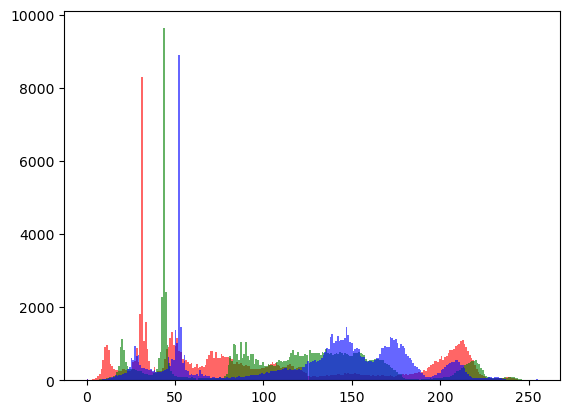

In [4]:
img = Image.open("prang.jpeg").convert("RGB")
pixels = np.array(img)

plt.hist(pixels[:,:,0].ravel(),bins = 256, color = 'red', alpha = 0.6)
plt.hist(pixels[:,:,1].ravel(),bins = 256, color = 'green', alpha = 0.6)
plt.hist(pixels[:,:,2].ravel(),bins = 256, color = 'blue', alpha = 0.6)
plt.show()

Above, the distribution of RGB values for the Windows background photo can be seen. While tempting, this plot mustn't be understood as a distribution of color intensity, but rather, as a distribution of color value by pixel. The count indicates how many pixels have an equal value of either red blue or green. The very tall green spike being positioned towards the right of the x-axis indicates that many pixels have very large values of green. This shouldn't be too surprising considering what the image is.

Now comes the tough part. A decision must be made regarding what the criterion for color selection will be. Many approaches can be taken, but initially, and as a test run, I will just take the mean value of each color channel (red, green and blue). Once I have a mean value, I will have a vector of 3 dimensions. To find the genre with the color most closely proximal to the image's mean RGB value, I will calculate the distance function $\sqrt{(\vec{x} - \vec{x_0})^2}$ and find the genre corresponding to the color which minimizes it.

In [5]:
color_photo = np.mean(pixels, axis = (0,1)).astype(int)         #averages over each channel

def distance(x,x0):
    return np.sqrt((x[0] - x0[0])**2 + (x[1] - x0[1])**2 + (x[2] - x0[2])**2)

distances = np.zeros(np.shape(genres)[0])

for i in range(np.shape(genres)[0]):
    distances[i] = distance(rgb_vals[i], color_photo)

min = np.argmin(distances)                                      #finds the index of the minimum distance

min_color = mcolors.to_rgb(genres[min,1])                       #finds the color corresponding to the min distance

Since this is a test after all, below I will plot the mean color of the image (taking by "mean" to be the average of each channel) next to the most proximal genre color from Every Noise. This will also print which genre corresponds to said color.

['jaw harp' '#6a7e80']


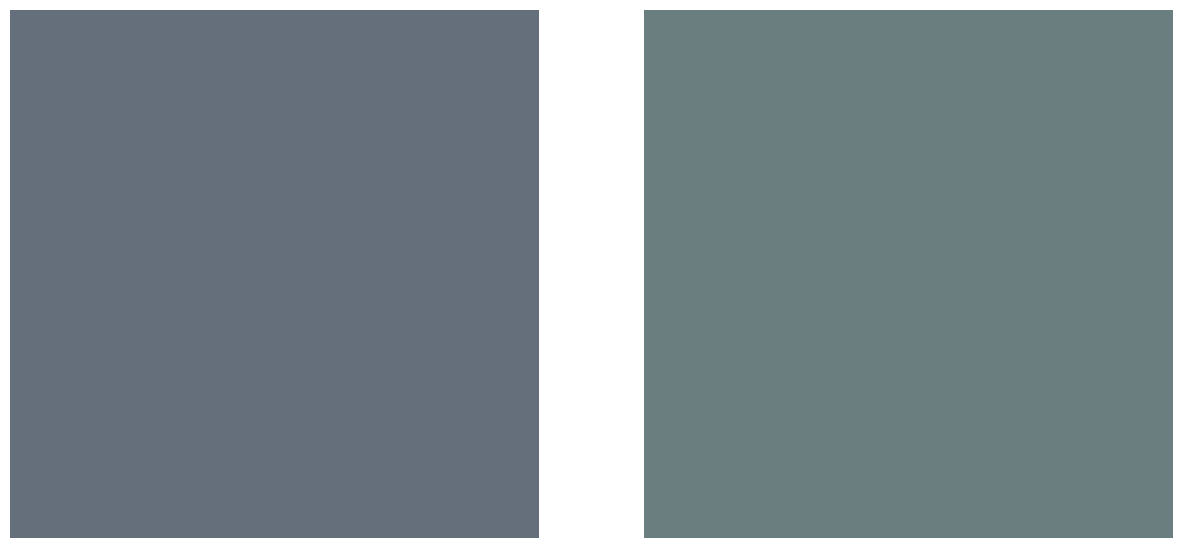

In [6]:
figs, axs = plt.subplots(1,2, figsize = (15,15))

square1 = np.ones((100,100,3))*color_photo/255
square2 = np.ones((100,100,3))*min_color

axs[0].imshow(square1, cmap=None)
axs[0].set_facecolor(color_photo/255)
axs[0].axis("off")

axs[1].imshow(square2, cmap=None)
axs[1].set_facecolor(min_color)
axs[1].axis("off")

print(genres[min])

It should be noted that this is a pretty barebones approach. Taking the mean over all channels strips the image of a lot of its information. Specifically, spatial distribution of color on the XY plane is completely lost by averaging out. Thus, more intricate methods will be used next in order to retain as much information as possible. The aim is to preserve as much of the image's uniqueness as possible.

The immediate alternative is to use some form of weighted average or even the mode, so first the mode will be implemented using SciPy.

In [7]:
mode_colors = np.array(stats.mode(pixels, axis = (0,1)))

distances_mode = np.zeros(np.shape(genres)[0])

for i in range(np.shape(genres)[0]):
    distances_mode[i] = distance(rgb_vals[i], mode_colors[0])

min_mode = np.argmin(distances_mode)                                      

min_color_mode = np.array(rgb_vals[min_mode])

print(min_color_mode)

[79. 98. 29.]


['rakugo' '#4f621d']


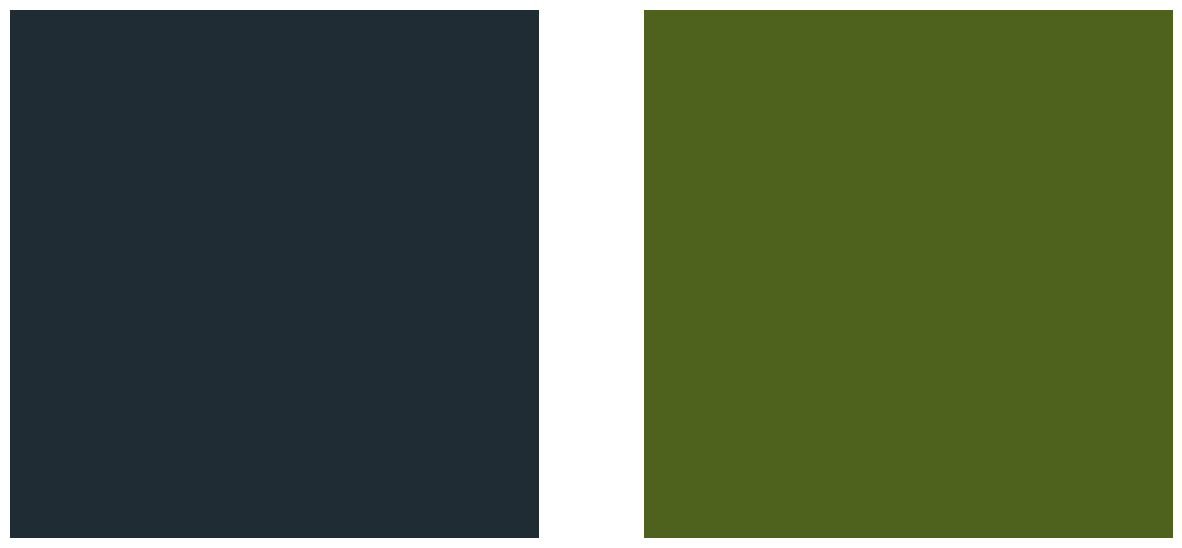

In [8]:
figs, axs = plt.subplots(1,2, figsize = (15,15))

square1 = np.ones((100,100,3))*mode_colors[0]/255
square2 = np.ones((100,100,3))*min_color_mode/255

axs[0].imshow(square1, cmap=None)
axs[0].set_facecolor(mode_colors[0]/255)
axs[0].axis("off")

axs[1].imshow(square2, cmap=None)
axs[1].set_facecolor(min_color_mode/255)
axs[1].axis("off")

print(genres[min_mode])

In [9]:
rgb = rgb_vals/255
modecol = mode_colors/255
minmode = min_color_mode/255

fig = go.Figure()

# RGB dataset
fig.add_trace(go.Scatter3d(
    x=rgb[:,0],
    y=rgb[:,1],
    z=rgb[:,2],
    mode='markers',
    marker=dict(
        size=3,
        color=rgb,
    ),
    name="dataset"
))

# mode color
fig.add_trace(go.Scatter3d(
    x=[modecol[0,0]],
    y=[modecol[0,1]],
    z=[modecol[0,2]],
    mode='markers',
    marker=dict(
        size=8,
        color=[f'rgb({modecol[0,0]*255},{modecol[0,1]*255},{modecol[0,2]*255})']
    ),
    name="mode"
))

# min mode color
fig.add_trace(go.Scatter3d(
    x=[minmode[0]],
    y=[minmode[1]],
    z=[minmode[2]],
    mode='markers',
    marker=dict(
        size=8,
        color=[f'rgb({minmode[0]*255},{minmode[1]*255},{minmode[2]*255})']
    ),
    name="min mode"
))

# line connecting them
fig.add_trace(go.Scatter3d(
    x=[modecol[0,0], minmode[0]],
    y=[modecol[0,1], minmode[1]],
    z=[modecol[0,2], minmode[2]],
    mode='lines',
    line=dict(color='black', width=5),
    name="connection"
))

fig.update_layout(
    width=800,
    height=800,
    scene=dict(
        xaxis_title='Red',
        yaxis_title='Green',
        zaxis_title='Blue',
        xaxis=dict(range=[0,1]),
        yaxis=dict(range=[0,1]),
        zaxis=dict(range=[0,1]),
    )
)

fig.show()

This is a concerning issue regarding the database. There is an under-representation of colors with very dark and very light tones. Looking at the 3D plot it is also noticeable that while red and blue values almost cover the whole spectrum, green values are capped below 0.8 and mostly stay above 0.2. This highlights an obvious issue with the methodology of minimizing the euclidean distance to select a color representative of the image, as it can be seen in this example. The selected color via this method may well look nothing like the source color itself. This issue will be resolved either expanding the database by incorporating a further amount of colors by scraping the artist database and not just the genres (this database is much, much, muc larger so this will be significantly complicated task), or devicing an alternative method to establish a color pairing. 